In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\cluster\test1\cluster\root_trait_RCC.csv")


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    b_std = 'b' + str(i) + '_std'
    b_name.append(b_std)


# b_name = np.array(b_name)
# b_name

In [4]:
cols_rdmc = b_name + ["CWM_log10_LDMC", "DS_relative_abund_sum", "ES_relative_abund_sum", "F_relative_abund_sum", "G_relative_abund_sum", "M_relative_abund_sum"]
cols_srl = b_name+ ["CWM_log10_SLA"]+ ["CWM_log10_LA"]+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rtd = b_name+ ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd = b_name+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]


cols_sra = b_name + ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rbd = b_name+ ["CWM_log10_LA"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rld = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcc = b_name+ ["CWM_log10_PC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rd13c = b_name+ ["CWM_Ld13C"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rnc = b_name+ ["CWM_log10_PN"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd15n = b_name+ ["CWM_Ld15N"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcn = b_name+ ["CN_ratio"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

In [5]:
x_RDMC = np.array(df_svc_RDMC[cols_rdmc] )
x_SRL = np.array(df_svc_SRL[cols_srl])
x_RTD = np.array(df_svc_RTD[cols_rtd])
x_RD = np.array(df_svc_RD[cols_rd])
x_SRA = np.array(df_svc_SRA[cols_sra])
x_RBD = np.array(df_svc_RBD[cols_rbd])
x_RLD = np.array(df_svc_RLD[cols_rld])
x_RD13C = np.array(df_svc_RD13C[cols_rd13c])
x_RNC = np.array(df_svc_RNC[cols_rnc])
x_RD15N = np.array(df_svc_RD15N[cols_rd15n])
x_RCN = np.array(df_svc_RCN[cols_rcn])
x_RCC = np.array(df_svc_RCC[cols_rcc])

In [6]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [7]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [8]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [9]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [10]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [11]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


Optimised number of PLS components:  22
Wavelengths to be kept  32
Optimised MSEP  47.03025017352744



[317.50315579 197.68164471 261.42524999 266.69559101 311.97906489
 211.67846699 217.32639179 324.12798683 264.65533858 267.79370213
 305.22391189 206.27606174 242.07870366 212.72919392 208.04773923
 285.2115958  282.17076354 301.70849108 260.39224377 334.93411999
 221.67783798 222.65498261 240.75341347 256.21563817 311.27525375
 289.17903368 206.76286493 386.48544324 248.6542288  226.61016956
 312.70566554 355.37371063 301.93559894 352.35073182 249.4142996
 253.47623493 362.49020278 278.83633167 368.15201254 325.20207682
 363.52372666 361.8237141  310.69403688 325.70847553 304.1009457
 329.78459301 312.45442218 319.61716932 348.0988051  315.69452314
 342.58635176 307.27818158 334.63994462 324.00519117 321.95464326
 322.41615962 330.2612951  327.31539667 306.8849857  346.26630889
 334.47712142 342.10806646 325.33370943 321.20490927 294.62085955
 335.61690386 345.22185892 308.88317696 324.75328344 315.92521657
 292.17095282 330.50496948 323.52908836 313.06815631 303.72939302
 274.2040041

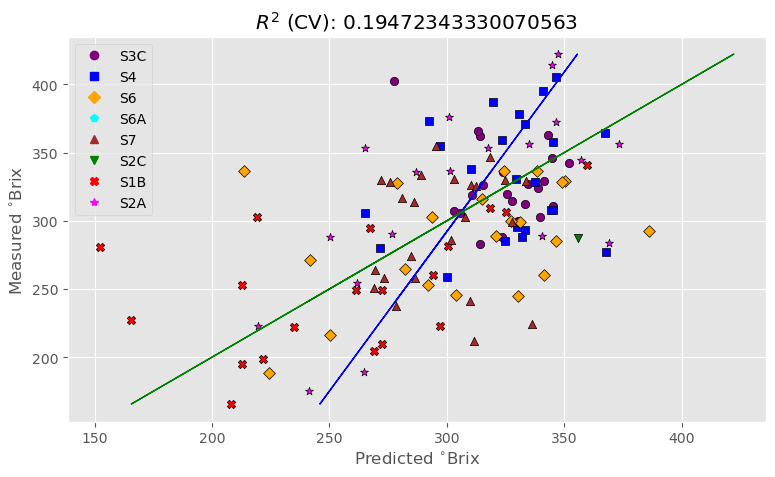

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)

## SRL

In [14]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  2
Wavelengths to be kept  22
Optimised MSEP  32.62190931517282



[ 90.49161388 139.81641626 120.07473502  95.06705535 106.46343582
 100.81363864  96.77627252 109.58748367 102.63089303  82.49013863
 109.80712687  82.21507535  96.94255587 115.76613551 140.37884019
 112.84439628 105.94472896 103.65966315 117.34166716 126.70640459
 103.01231394 121.85904873 136.12425835 114.17498437  45.00320242
  39.59391721  44.05905979  38.49635758  52.9031963   54.10834252
  53.99597582  26.62603426  69.84820814  77.72391834  66.85417784
  34.93031627  62.02369541  58.29455292  53.12468001  69.20081655
  52.95493129  86.94213658 139.46864833 142.27987456 108.70427435
 127.59796905 137.33028971 123.03947505 122.35380307 119.43778377
 131.3026146  122.18936028 143.76838168 139.33073732 135.10847054
 131.90597697 129.75883024 140.54822332 123.16773486 121.72221443
 128.81762178 142.84991121 117.70186518 126.67762742 130.00458575
 126.50263521 130.38462828 114.1089911  129.43095469 134.62090572
 119.65136781 131.46575431 120.81731101 130.41795147 133.19001803
 111.88591

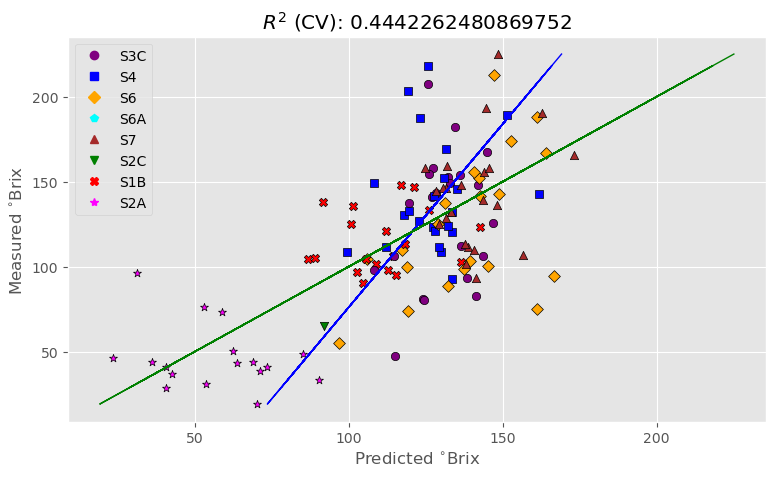

In [15]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

## RTD
 

In [16]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 25)


Optimised number of PLS components:  24
Wavelengths to be kept  81
Optimised MSEP  0.08049182173214792



[0.60674486 0.49549818 0.40970953 0.41907716 0.48025479 0.34029023
 0.34287134 0.23285183 0.43912032 0.46562074 0.42416172 0.41375956
 0.31145895 0.35799685 0.37299848 0.43834456 0.43467521 0.56643483
 0.46278566 0.60628254 0.48779669 0.47288283 0.44959112 0.48989053
 0.38603765 0.26381013 0.33310297 0.6321974  0.54590138 0.64085766
 0.40267362 0.6212004  0.42734048 0.52676754 0.48921745 0.38453977
 0.65017533 0.51363878 0.44235759 0.57695203 0.74440345 0.26598746
 0.47669135 0.50052756 0.44392398 0.47786762 0.48838746 0.50124757
 0.46754897 0.40450759 0.47087314 0.52412724 0.4137104  0.44172189
 0.50021354 0.40803887 0.48684584 0.49812375 0.47700706 0.48627195
 0.48861184 0.44485098 0.44932859 0.52656897 0.57134397 0.52632954
 0.56470518 0.56858475 0.5563774  0.52567697 0.56940703 0.37332336
 0.61309952 0.5533682  0.54500311 0.5641912  0.40059046 0.52493021
 0.55511132 0.54547503 0.49518358 0.53731275 0.5600319  0.56291447
 0.54169982 0.42616092 0.35631226 0.42539464 0.44606634 0.4737

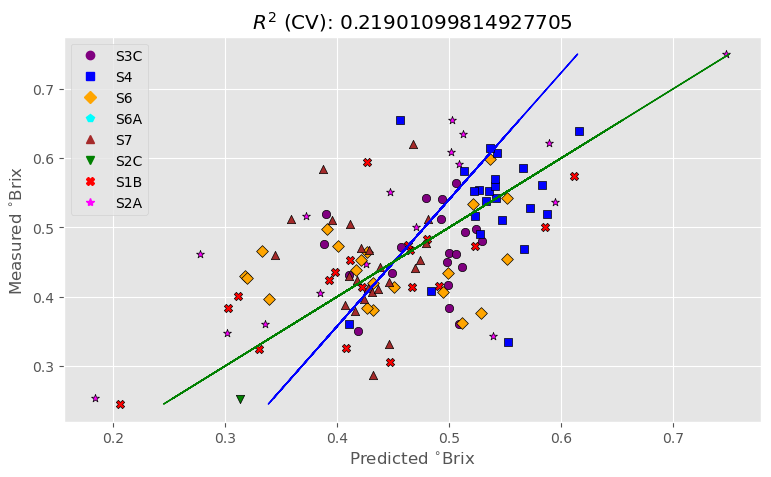

In [17]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [18]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 20)


Optimised number of PLS components:  18
Wavelengths to be kept  97
Optimised MSEP  0.02760669134341005



[0.19975544 0.16395535 0.16341752 0.17590612 0.16052194 0.20257417
 0.18444077 0.19920315 0.18756668 0.15052347 0.17347868 0.17709464
 0.15166871 0.17831002 0.15671652 0.16076384 0.17165956 0.1491708
 0.14381396 0.13612364 0.13782023 0.16025302 0.16603115 0.13436394
 0.29760789 0.22609415 0.21926735 0.25085002 0.22595542 0.26903502
 0.27680928 0.21955289 0.26352989 0.24263056 0.34283365 0.26872618
 0.21279567 0.24568021 0.19871456 0.22160476 0.24597002 0.27907415
 0.16043373 0.13040221 0.17838869 0.16662396 0.14507617 0.14770074
 0.15802417 0.17186991 0.14749781 0.13329849 0.14669982 0.16116362
 0.16811932 0.17014364 0.14764447 0.15733846 0.14457386 0.15236718
 0.15999135 0.13380194 0.19878798 0.13561776 0.13539832 0.12904783
 0.14060535 0.14920069 0.12790053 0.12353467 0.1355284  0.15541251
 0.12436974 0.17318238 0.12073477 0.13036198 0.11933988 0.13907345
 0.17638967 0.13047266 0.11294676 0.12605618 0.1150315  0.137652
 0.12276209 0.116422   0.13323378 0.13234347 0.17226535 0.1779468

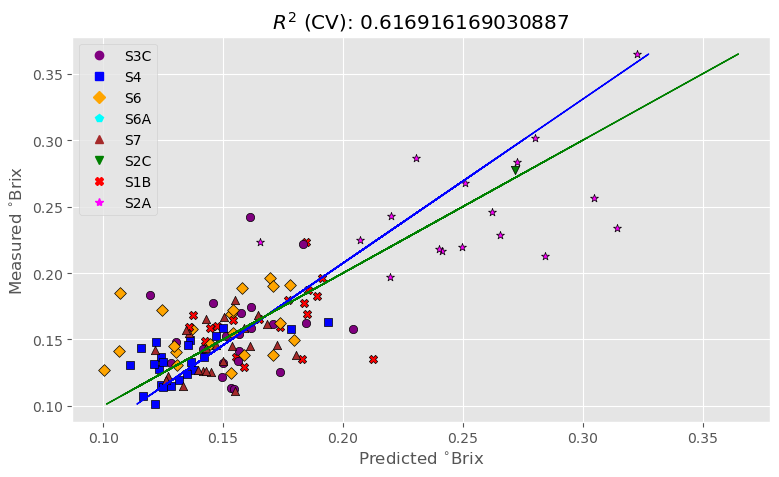

In [19]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# SRA

In [20]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  24
Wavelengths to be kept  71
Optimised MSEP  103.15605104814972



[295.05548555 479.36644176 500.14541162 542.44361418 520.53992758
 597.68280787 708.46856418 736.49603167 526.41825414 516.34786795
 584.48483125 527.47782852 715.99450877 565.99880799 594.38526467
 557.82922859 516.94977726 450.07381078 636.89729139 548.06409246
 573.45914065 659.18612631 511.52112135 559.14316261 346.95560701
 669.90785766 481.53880891 250.37710982 335.39826013 218.31529509
 357.18037265 323.50556323 375.75780746 351.66092549 187.4184437
 411.4611517  271.26902928 336.79891543 448.13767777 326.84991457
 222.51316783 547.69981356 560.10332594 532.53730628 528.24986708
 594.68034429 583.89097285 586.75536719 544.52675166 624.26726529
 612.89850527 695.81369522 646.34767    589.11170556 608.9993338
 549.05073071 532.57929698 458.65897074 577.38642819 568.54769844
 595.83574594 487.14587356 546.27827762 752.36768684 637.0904553
 510.48159199 528.1131868  554.76700051 559.24326422 573.22578127
 558.58693192 546.717466   728.36952011 546.91967191 553.52294665
 554.26378304

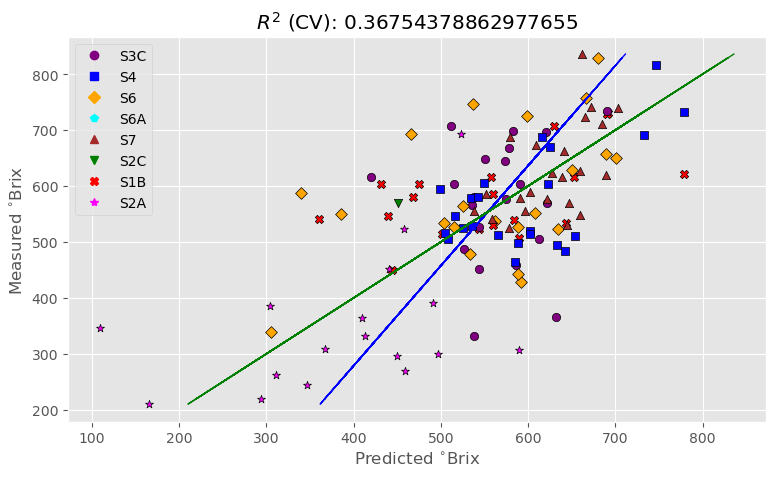

In [21]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## RBD

In [22]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 25)



Optimised number of PLS components:  22
Wavelengths to be kept  93
Optimised MSEP  0.0029001546739555674



[ 0.00798979  0.00835291  0.00580968  0.01770785  0.01103791  0.00893456
  0.00855777  0.00545177  0.0135472   0.00246423  0.00428256  0.01241534
  0.01249513  0.00927677  0.01817305  0.00288198  0.00185091  0.00848728
  0.00212446  0.00220638  0.00483962  0.00078117  0.00031063  0.00174246
  0.0012193   0.0025446   0.00421895  0.00618395  0.00585152 -0.00025926
  0.0049117   0.01364557  0.00357516  0.00162595  0.0009431   0.00863422
  0.00674505  0.00265116  0.0001113   0.00266053  0.00186     0.0052996
  0.00222077  0.00172829  0.00430785  0.00399632  0.00338571  0.00260416
  0.0072301   0.0037495   0.00229817  0.00298774  0.00048197  0.00226152
  0.00288005  0.0026025   0.00430775  0.00292828  0.00262526  0.00063239
  0.00127906  0.00180482  0.00188203  0.00301106  0.00401486  0.00251021
  0.0040616   0.00019028  0.00195331  0.00153637  0.00283132  0.00424251
 -0.00023385  0.00013856  0.00277482  0.00230673  0.00207006  0.00404167
  0.00360462  0.00584599  0.00637721  0.0049607 ]
R2

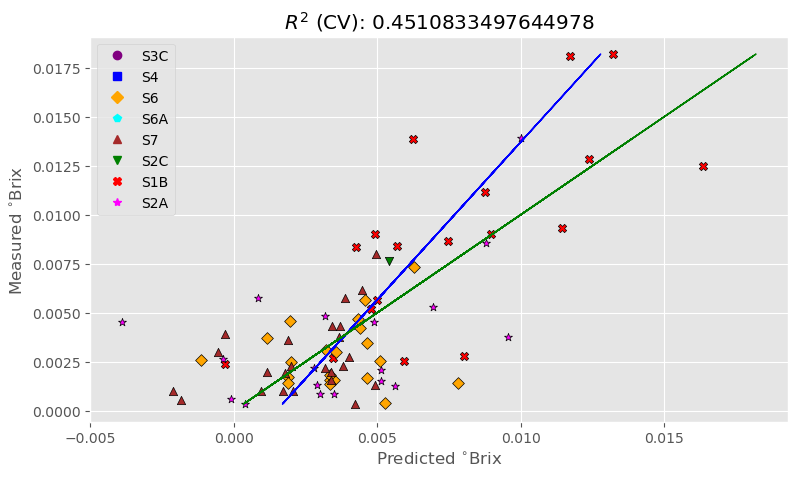

In [23]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [14]:
df_svc_RBD['site'][29]

'S2A_Q17'

## RLD

In [24]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  13
Wavelengths to be kept  65
Optimised MSEP  2.9773635286113556



[ 3.50987443  4.26542895  6.11835805  1.5653049   3.85559563  3.16232285
  6.04752688  3.268635    9.18332308  5.96188263  5.43486988  4.83997014
  8.33911882  3.76434416  5.14238543  3.61338845  2.70108492  6.7685063
  3.51657435  6.11203472  8.75654905  6.36370626  4.14323192  5.75713236
  5.01219378  0.77101434  2.74066704  1.67573427  2.02801684  1.58296241
  1.90102022  2.0146858   4.23414099  3.8606903   1.28377195  1.38346146
  4.46913172  3.10034356  1.10063919  0.92290568  0.5143099   3.69978006
 10.388517    7.23640752  6.42803396  7.33104676  7.87166615  6.06712091
  6.05562547  4.24071453  5.16793892  9.22609908  6.60523523  5.65136609
  4.44553794  7.60385601  4.32866538  8.69339521  5.12901985  6.70818615
  5.74409432  6.28653217  3.4881349   4.94967905  7.57363205  6.59552959
  7.26642874  6.26167151  9.35004896  6.63523424  7.73902602  8.13914048
  5.92379383  4.73012176  9.24718801  6.0190763   7.03015833  7.32597618
  3.38766049  9.13019282  8.09196239  7.3689345   7.

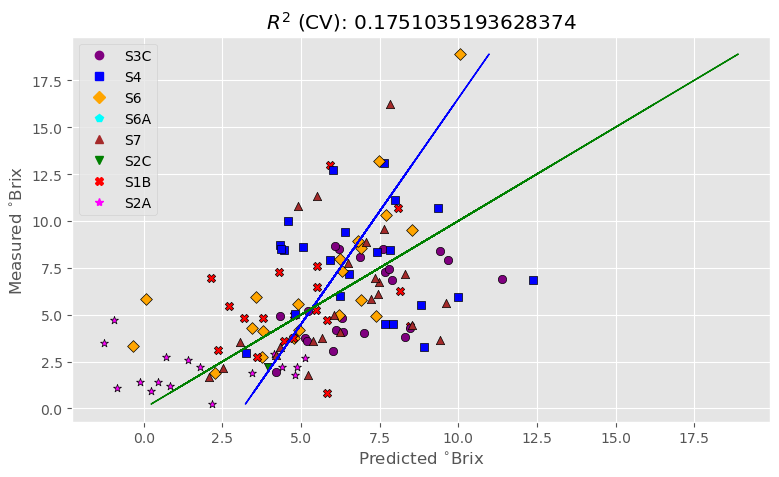

In [25]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [26]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  3
Wavelengths to be kept  26
Optimised MSEP  0.8401198121945164



[-28.77341536 -28.63539032 -28.53310617 -28.48017062 -28.37073995
 -28.81846548 -28.71001369 -28.4265528  -28.5780183  -27.88866334
 -27.6582059  -28.56369055 -27.85504261 -28.77933144 -27.91976957
 -28.16847186 -28.13675896 -28.24483894 -27.93033088 -27.51235473
 -28.33081298 -26.77562022 -26.86137495 -27.88143774 -27.85320616
 -28.42849921 -28.55395324 -28.50238586 -28.60614982 -28.75256358
 -28.31887237 -28.30029377 -28.30658183 -28.14603661 -27.90659755
 -28.17971943 -27.89389972 -27.87208973 -28.43338658 -28.1224377
 -27.95140476 -27.94297004 -27.80731845 -27.90586815 -28.37488979
 -27.75003318 -27.84955171 -27.43718108 -27.76263214 -27.26672752
 -28.1043095  -27.5788724  -27.81647191 -27.99575496 -28.07834949
 -28.07356118 -27.97832817 -27.63347399 -27.91735304 -27.89671414
 -27.71789677 -27.91506341 -27.65131773 -27.71291383 -28.99906247
 -28.65502117 -28.87422391 -28.0948886  -28.01266769 -28.28181615
 -28.38781956 -28.09766275 -27.89107767 -27.64536395 -27.86913137
 -28.296786

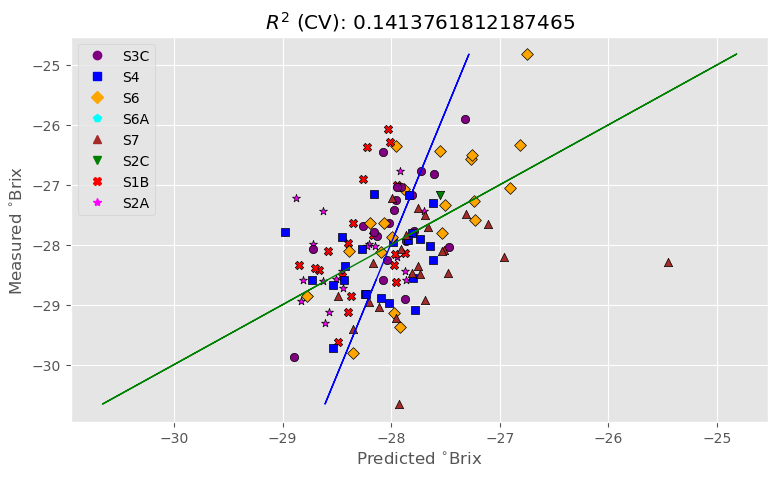

In [27]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  4
Wavelengths to be kept  57
Optimised MSEP  1.7760631013581527

[11.41017993 12.32238018 11.11198747  9.12944943 10.36890656 11.65463592
 10.48828121 11.39416048  9.68932506  7.88804986  9.53094921  7.61894673
 10.58374486  8.25127411 10.96130685  8.74226034  8.88954734  8.24739486
 10.1430691   7.93592082  8.78197719 11.06180787  6.95243498  6.28512533
  9.39277389 10.78282125 10.00006205 11.26703289 11.74076756 12.53063042
 12.28222004 11.34770217 10.39710487 13.03728773  9.76342077  9.98510389
  9.58719913  9.61806709 10.00702747 12.31748939  9.09198541  8.95370272
  8.82871896  8.82331871  9.60228026 10.70682702  9.20425283 10.49248219
 10.70218464  9.0503764  10.24461929  9.27243178 10.25203151  9.63940948
  9.93630194 10.99067741 10.09160688 10.57126556  9.97221595  9.98668619
  9.86215998  9.23076696 10.35986372  9.50691633 10.14447724 10.33275661
 12.30543187 11.47221592 10.98650517  9.63609285  9.33395552 10.03945086
 10.84850462  9.36135

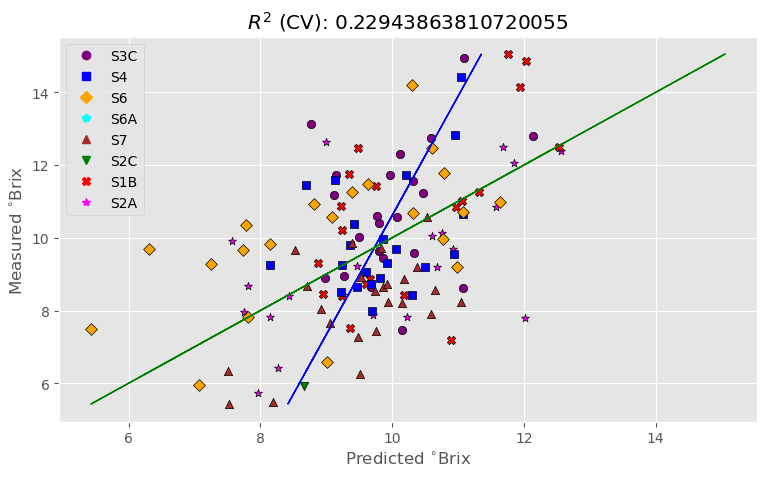

In [28]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  18
Wavelengths to be kept  90
Optimised MSEP  1.3641081006229834

[ 1.97602072e+00  2.97511584e-01  1.72218008e+00  2.20201658e+00
  1.43764758e+00  1.13088220e+00 -1.12584721e-01 -1.01080340e+00
 -1.14611434e+00 -9.71971987e-01 -1.59425247e+00  1.15322526e-01
  3.44202186e-01 -5.00504180e+00  2.96667019e-01 -4.32546158e+00
 -7.01798675e-01 -5.16440566e-01 -2.62067456e+00 -1.02494614e-01
  9.40896329e-01 -2.51172943e+00  2.72504393e+00  3.05836332e+00
  2.39510870e+00  2.58850806e+00  4.26064575e-01  1.10730473e+00
  2.06148871e+00  6.34854612e-01  1.60789248e+00  2.97587655e+00
  1.68201561e+00  1.18096618e+00  1.70512291e+00  4.22510535e+00
  6.60645398e-01 -6.89560321e-01 -9.83131349e-01  1.37472806e+00
 -1.69086558e-01  2.50767317e+00  1.11936107e+00 -1.91794104e-01
  7.28375590e-01  1.32444453e+00 -2.34700283e-01 -6.86858052e-02
  6.04114129e-01  1.33739306e+00 -9.64000851e-02  8.68464549e-01
 -1.11796141e-01  8.14162592e-02 -5.84075371e-01 -8

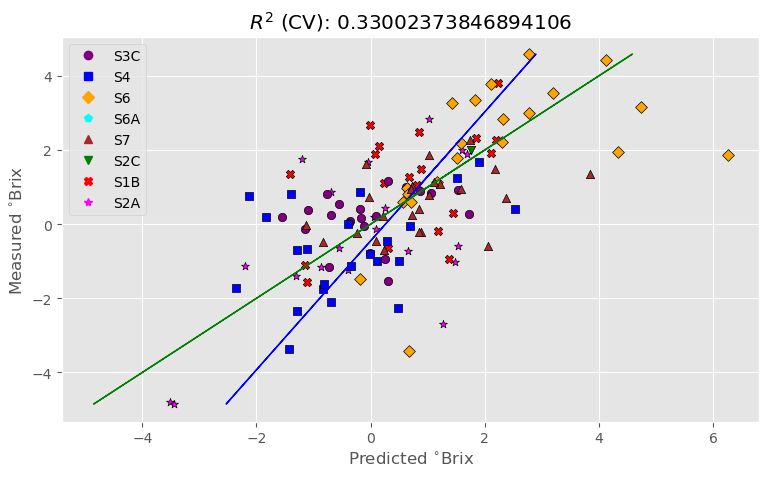

In [29]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  10
Wavelengths to be kept  26
Optimised MSEP  9.044677531802389

[43.12107174 40.27523094 45.03918322 55.92200679 45.26120526 34.88776774
 46.96920211 52.0257091  59.25761886 65.14939126 63.47289127 67.00674555
 51.48255524 67.07833846 49.30693655 60.90114555 65.16222782 55.94759163
 61.18194513 60.35990251 66.46794848 42.94782604 52.77125472 61.61985056
 44.90402203 36.23969944 50.55403165 41.02229734 41.0764167  31.69403915
 33.4347029  36.13220197 41.30888408 32.25054461 48.03819912 48.62202365
 55.68931449 51.96586886 43.82201458 31.17353602 56.81023527 50.47938747
 55.49943928 52.24145788 52.79802786 48.39468029 45.93473541 47.43736799
 43.34516169 50.71328752 45.77173267 47.44881466 44.12821744 45.9680173
 47.19187225 39.4582914  47.44179207 44.23554877 48.08857469 46.77055299
 48.07605563 54.92752629 47.32649756 49.77621997 42.0427515  42.65069537
 32.42970827 34.21892276 37.3532473  43.50507491 46.79417284 40.94291119
 38.45644122 46.187634

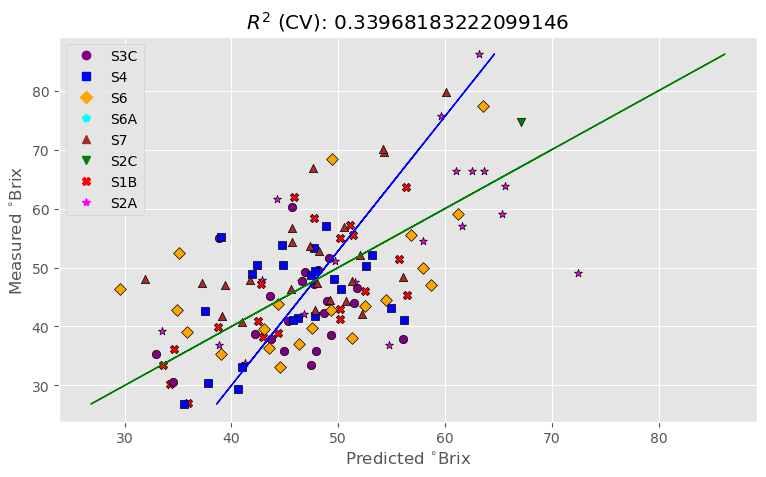

In [30]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  9
Wavelengths to be kept  31
Optimised MSEP  25.619196800161408

[470.05854    475.56262457 441.86158405 497.85451574 443.62445045
 487.71600955 482.30983218 475.53901506 484.85964247 486.5193471
 499.46228656 492.98289699 501.53429533 493.78646554 455.82292954
 492.55359272 495.47944004 482.16298004 533.26050309 501.40138114
 460.93129044 452.8221958  437.4288688  457.90317289 473.55524686
 450.27362623 467.64872734 453.74730831 424.86079406 438.15224966
 437.58813725 461.57424347 414.54876217 457.03360975 457.6459604
 463.52147589 500.49999207 480.05335643 489.4997737  487.95216969
 454.49605945 471.52694805 469.12458049 458.99032781 466.4732927
 459.31015933 434.33815419 426.49396964 464.78614272 441.76040927
 453.0205463  447.19282437 437.6661844  459.68740921 450.49735019
 444.8949017  449.52829862 444.76756716 448.91049391 456.85117386
 454.05776061 449.47880763 492.2193774  476.12236731 463.58754665
 453.60235497 456.83111074 453.35275658 43

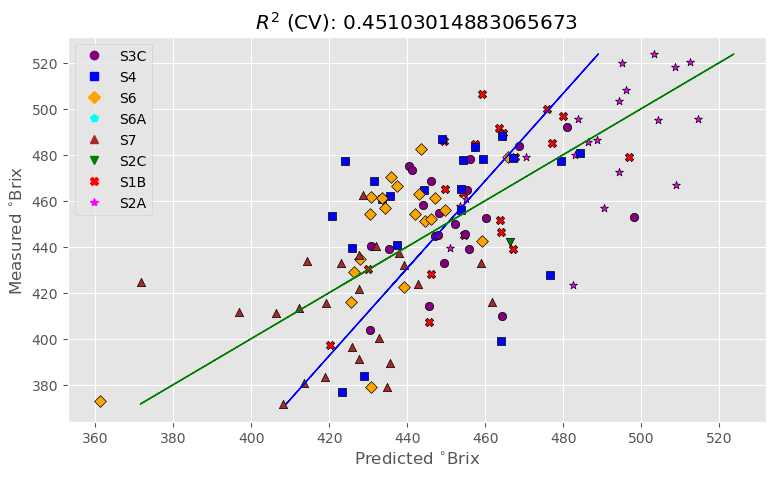

In [31]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
